<a href="https://colab.research.google.com/github/chyla-dafinah/analisis-dan-visualisasi-data/blob/main/Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q kaggle

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"chylaamalia","key":"57fbe819e9b0f98b5b2b4a1349ae77d2"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d carrie1/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 116MB/s]



In [9]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: data.csv                


In [11]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [13]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [14]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [15]:
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [18]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [19]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

In [20]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

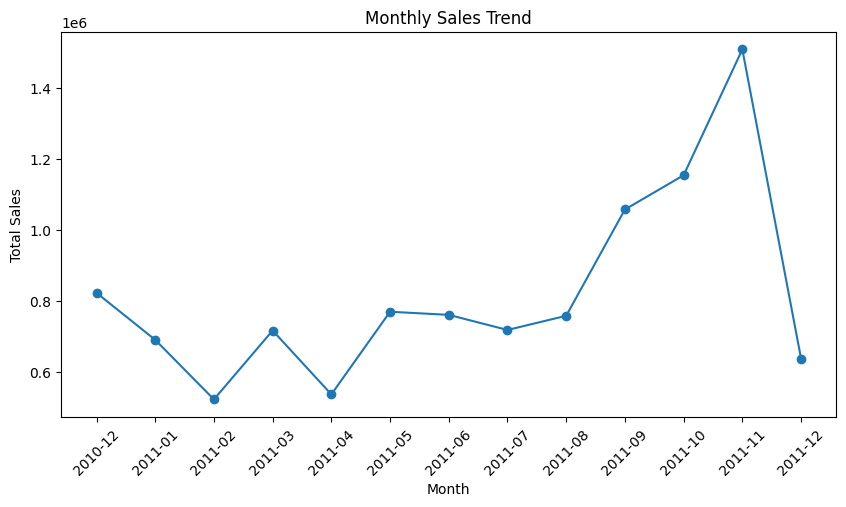

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.xticks(rotation=45)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

In [22]:
avg_price = df['UnitPrice'].mean()

underperform = df[df['UnitPrice'] > avg_price]

underperform.groupby('Description')['Quantity'].sum().sort_values().head(10)

,Quantity
Description,
YELLOW FLOWERS FELT HANDBAG KIT,1
I LOVE LONDON MINI RUCKSACK,1
YELLOW EASTER EGG HUNT START POST,1
3 RAFFIA RIBBONS VINTAGE CHRISTMAS,1
FIRE POLISHED GLASS NECKL GOLD,1
FRYING PAN RED POLKADOT,1
FRIDGE MAGNETS LES ENFANTS ASSORTED,1
6 RIBBONS SHIMMERING PINKS,1
FLAMES SUNGLASSES PINK LENSES,1


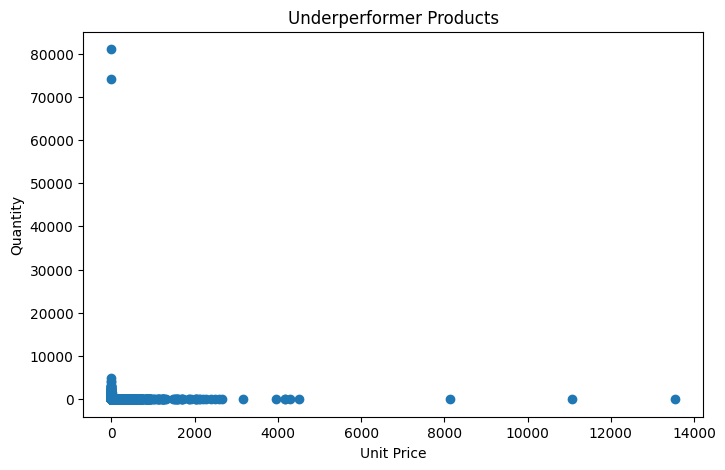

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(df['UnitPrice'], df['Quantity'])

plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.title('Underperformer Products')

plt.show()

In [24]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [28]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,182,4310.00,5,5,5,555
12348.0,75,31,1797.24,2,3,4,234
12349.0,19,73,1757.55,4,4,4,444
12350.0,310,17,334.40,1,2,2,122


In [29]:
avg_price = df['UnitPrice'].mean()

underperform = df[df['UnitPrice'] > avg_price]

underperform_product = (
    underperform.groupby('Description')['Quantity']
    .sum()
    .sort_values()
    .head(10)
)

print(underperform_product)

Description
YELLOW FLOWERS FELT HANDBAG KIT        1
 I LOVE LONDON MINI RUCKSACK           1
YELLOW EASTER EGG HUNT START POST      1
3 RAFFIA RIBBONS VINTAGE CHRISTMAS     1
FIRE POLISHED GLASS NECKL GOLD         1
FRYING PAN RED POLKADOT                1
FRIDGE MAGNETS LES ENFANTS ASSORTED    1
6 RIBBONS SHIMMERING PINKS             1
FLAMES SUNGLASSES PINK LENSES          1
WHITE BIRD GARDEN DESIGN MUG           1
Name: Quantity, dtype: int64
